In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
# CELL 2: Robust Data Ingestion
import os
import pandas as pd

# Dynamically route the path whether the kernel is rooted in workspace root or /notebooks
base_dir = "." if os.path.exists("data") else ".."
enriched_path = os.path.join(base_dir, "data", "Master_Enriched_Grid_Telemetry.csv")
forecast_path = os.path.join(base_dir, "data", "Grid_Demand_Forecast_Horizon.csv")

grid_df = pd.read_csv(enriched_path)
forecast_df = pd.read_csv(forecast_path)

# Convert string timestamps to Datetimes
grid_df['READ_DTTM'] = pd.to_datetime(grid_df['READ_DTTM'])
forecast_df['READ_DTTM'] = pd.to_datetime(forecast_df['READ_DTTM'])

print(f"Cell 2: Master Grid loaded      -> Shape: {grid_df.shape}")
print(f"Cell 2: Forecast Horizon loaded -> Shape: {forecast_df.shape}")

Cell 2: Master Grid loaded      -> Shape: (66822, 13)
Cell 2: Forecast Horizon loaded -> Shape: (2228, 8)


In [3]:
# CELL 3: Revenue Protection Audit & Financial Quantification
TARIFF_PER_KWH = 7.50  # INR (Uttar Pradesh Standard Industrial Baseline)

print("--- 1. MASTER DIAGNOSTIC BREAKDOWN ---")
audit_counts = grid_df['Grid_Diagnostic_State'].value_counts()
print(audit_counts.to_string())

# Isolate the Confirmed Bypassed ticks
theft_df = grid_df[grid_df['Grid_Diagnostic_State'] == 'Confirmed Theft: Unmetered Physical Line Bypass']

# Physics Formula: (Volts * Amps * 0.25 hours) / 1000 = kWh bypassed per 15-min tick
stolen_kwh = (theft_df['UP - Average Voltage'] * theft_df['UP - Average Current'] * 0.25) / 1000.0
total_kwh_lost = stolen_kwh.sum()
total_inr_lost = total_kwh_lost * TARIFF_PER_KWH

print("\n--- 2. FISCAL LEAKAGE REPORT ---")
print(f"Total Unmetered Power Leaked : {total_kwh_lost:,.2f} kWh")
print(f"Total Direct Rupee Loss      : ₹ {total_inr_lost:,.2f}")

--- 1. MASTER DIAGNOSTIC BREAKDOWN ---
Grid_Diagnostic_State
Grid Outage / Total Disconnect                        33204
Normal Consumption                                    19590
Confirmed Theft: Unmetered Physical Line Bypass       13725
Technical Fault: Terminal Cover Open / Battery Low      301
Critical Alarm: Magnetic Saturation Tampering             2

--- 2. FISCAL LEAKAGE REPORT ---
Total Unmetered Power Leaked : 3,619.87 kWh
Total Direct Rupee Loss      : ₹ 27,149.05


In [4]:
# CELL 4: Slice the 7-Day Macro Horizon
week_ticks = 96 * 7
macro_df = forecast_df.iloc[:week_ticks].copy()

print(f"Cell 4: Macro view sliced -> Rows: {len(macro_df)}")

Cell 4: Macro view sliced -> Rows: 672


In [5]:
# CELL 5: Slice the 24-Hour Micro Horizon (Day 3 of Forecast)
day_ticks = 96
micro_df = forecast_df.iloc[day_ticks*2 : day_ticks*3].copy()

print(f"Cell 5: Micro view sliced -> Rows: {len(micro_df)}")

Cell 5: Micro view sliced -> Rows: 96


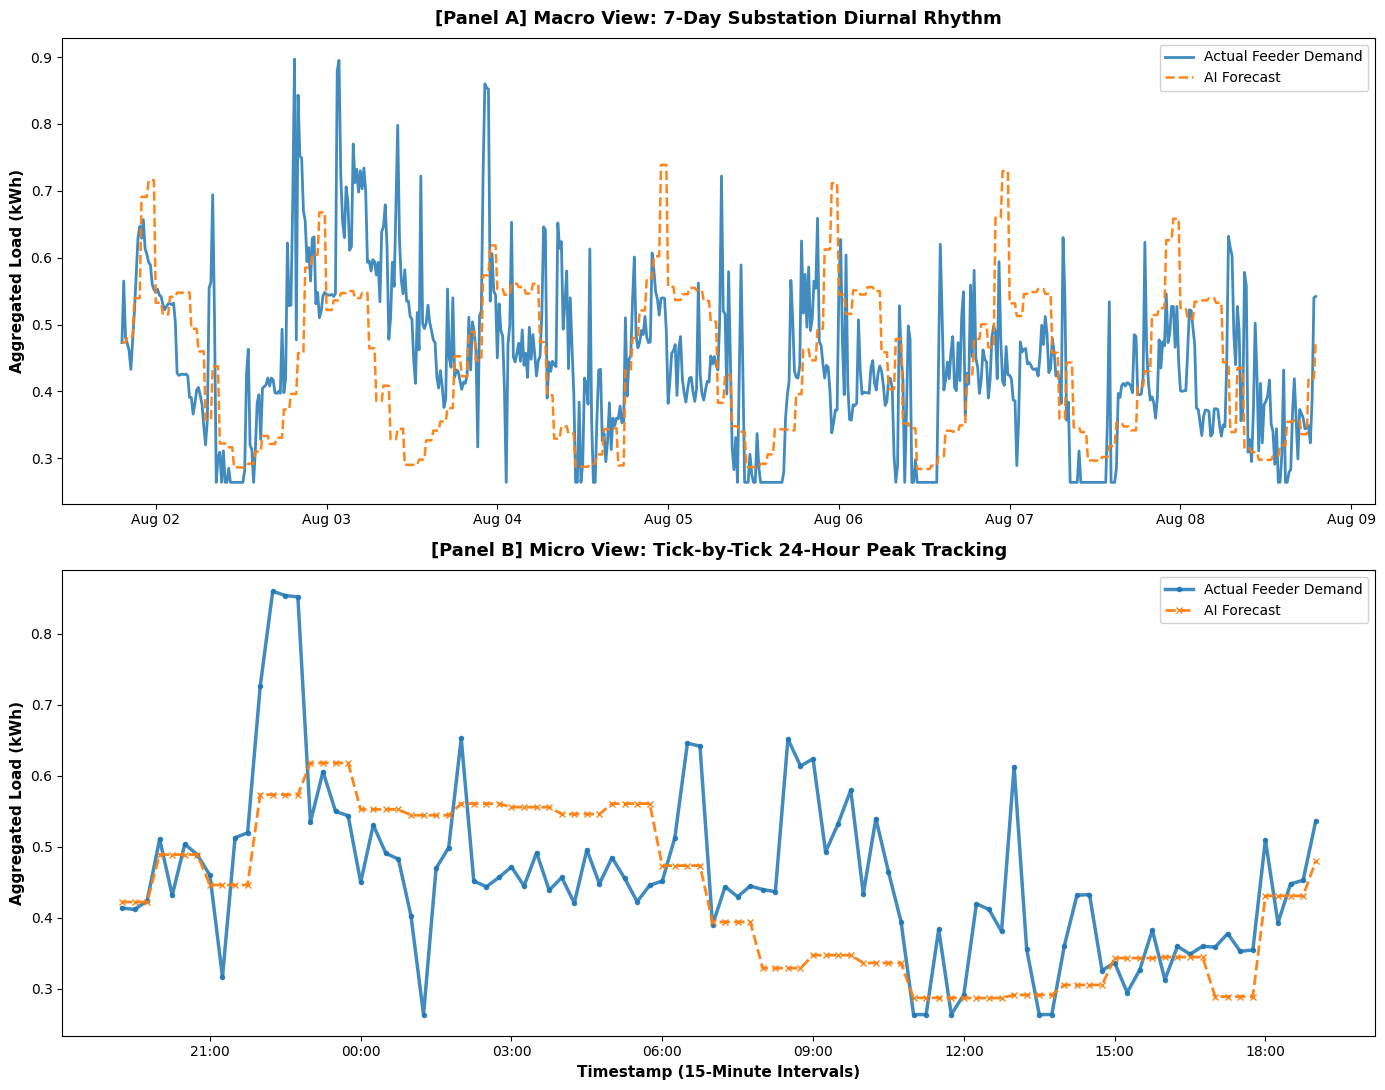

Cell 6: De-clustered multi-panel figure saved to -> '.\data\Figure_4.4_Declustered_Forecast.png'


In [6]:
# CELL 6: De-clustered Multi-Panel Forecast Visualization
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(14, 11))

# ------------------------------------------------------------------------------
# GRAPH 1: MACRO VIEW (7-DAY HORIZON)
# ------------------------------------------------------------------------------
ax1.plot(macro_df['READ_DTTM'], macro_df['Substation_Demand_KWH'], 
         label='Actual Feeder Demand', color='#1f77b4', linewidth=2.0, alpha=0.85)
ax1.plot(macro_df['READ_DTTM'], macro_df['AI_Forecasted_Demand_KWH'], 
         label='AI Forecast', color='#ff7f0e', linewidth=1.8, linestyle='--', alpha=0.95)

ax1.set_title('[Panel A] Macro View: 7-Day Substation Diurnal Rhythm', fontsize=13, fontweight='bold', pad=10)
ax1.set_ylabel('Aggregated Load (kWh)', fontsize=11, fontweight='bold')
ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
ax1.xaxis.set_major_locator(mdates.DayLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

# ------------------------------------------------------------------------------
# GRAPH 2: MICRO VIEW (24-HOUR PEAK INSPECTION)
# ------------------------------------------------------------------------------
ax2.plot(micro_df['READ_DTTM'], micro_df['Substation_Demand_KWH'], 
         label='Actual Feeder Demand', color='#1f77b4', linewidth=2.5, alpha=0.85, marker='o', markersize=3)
ax2.plot(micro_df['READ_DTTM'], micro_df['AI_Forecasted_Demand_KWH'], 
         label='AI Forecast', color='#ff7f0e', linewidth=2.0, linestyle='--', alpha=0.95, marker='x', markersize=4)

ax2.set_title('[Panel B] Micro View: Tick-by-Tick 24-Hour Peak Tracking', fontsize=13, fontweight='bold', pad=10)
ax2.set_xlabel('Timestamp (15-Minute Intervals)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Aggregated Load (kWh)', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.9)
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()

# Safely serialize the high-resolution composite figure
output_dir = "." if os.path.exists("data") else ".."
save_path = os.path.join(output_dir, "data", "Figure_4.4_Declustered_Forecast.png")
plt.savefig(save_path, dpi=300)
plt.show()

print(f"Cell 6: De-clustered multi-panel figure saved to -> '{save_path}'")